# VIPER Model — Model Training & Evaluation

**Pipeline stage:** 3 of 6  
**Input:** `clinvar_features_engineered.tsv`  
**Outputs:** `rf_model_tuned.pkl`, `xgb_model_tuned.pkl`, `model_config.json`, figures `plot_01_` → `plot_05_`  

---

## Contents
1. [Imports & Data Loading](#1-imports--data-loading)
2. [Train/Test Split](#2-trainttest-split)
3. [Pre-training Feature Check](#3-pre-training-feature-check)
4. [Class Imbalance Analysis](#4-class-imbalance-analysis)
5. [Baseline Model Comparison](#5-baseline-model-comparison)
6. [Hyperparameter Tuning (GridSearchCV)](#6-hyperparameter-tuning)
7. [Tuned Model Evaluation](#7-tuned-model-evaluation)
   - 7.1 ROC Curve with Bootstrap CI
   - 7.2 Precision-Recall Curve & Clinical Threshold Selection
8. [Three-Zone Classification](#8-three-zone-classification)
9. [Visualisation Suite](#9-visualisation-suite)
   - Plot 1: Confusion Matrix
   - Plot 2: Probability Distribution
   - Plot 3: Three-Zone Breakdown
   - Plot 4: Confidence Zone Accuracy
   - Plot 5: Misclassification Analysis (FN + FP)
10. [Artefact Export](#10-artefact-export)


## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, time, os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

COLORS = {'Pathogenic': '#D7191C', 'Benign': '#2C7BB6', 'VUS': '#FDAE61'}

df = pd.read_csv('clinvar_features_engineered.tsv', sep='\t', low_memory=False)
print(f'Shape: {df.shape}')
print(f'\nLabel distribution:')
print(df['label_group'].value_counts())

Shape: (104639, 25)

Label distribution:
label_group
VUS           40894
Benign        40169
Pathogenic    23576
Name: count, dtype: int64


## 2. Train/Test Split

- Only Pathogenic/Benign variants enter training (binary classification).
- VUS are held out entirely for downstream reclassification.
- Stratified 80/20 split on binary label ensures class balance is preserved across sets.


In [2]:
feature_cols = [
    'PHRED', 'MAX_AF', 'PolyPhen_score',
    'IMPACT_encoded', 'VARIANT_CLASS_encoded', 'BIOTYPE_encoded',
    'SIFT_cat_encoded', 'PolyPhen_cat_encoded', 'Consequence_grouped_encoded'
]

train_pool = df[df['label_group'].isin(['Pathogenic', 'Benign'])].copy()
vus_data   = df[df['label_group'] == 'VUS'].copy()

train_pool['label'] = (train_pool['label_group'] == 'Pathogenic').astype(int)

X = train_pool[feature_cols]
y = train_pool['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set:   {len(X_train):,} variants')
print(f'  Pathogenic:   {(y_train==1).sum():,}')
print(f'  Benign:       {(y_train==0).sum():,}')
print(f'\nTest set:       {len(X_test):,} variants')
print(f'  Pathogenic:   {(y_test==1).sum():,}')
print(f'  Benign:       {(y_test==0).sum():,}')
print(f'\nVUS (held out): {len(vus_data):,} variants')

Training set:   50,996 variants
  Pathogenic:   18,861
  Benign:       32,135

Test set:       12,749 variants
  Pathogenic:   4,715
  Benign:       8,034

VUS (held out): 40,894 variants


## 3. Pre-training Feature Check

Verify feature correlation on the training set.  
`SIFT_score` was dropped after initial inspection due to high correlation with `PolyPhen_score`.  
Final feature set uses 9 features.  
`→ saves: feature_correlation_final.png`

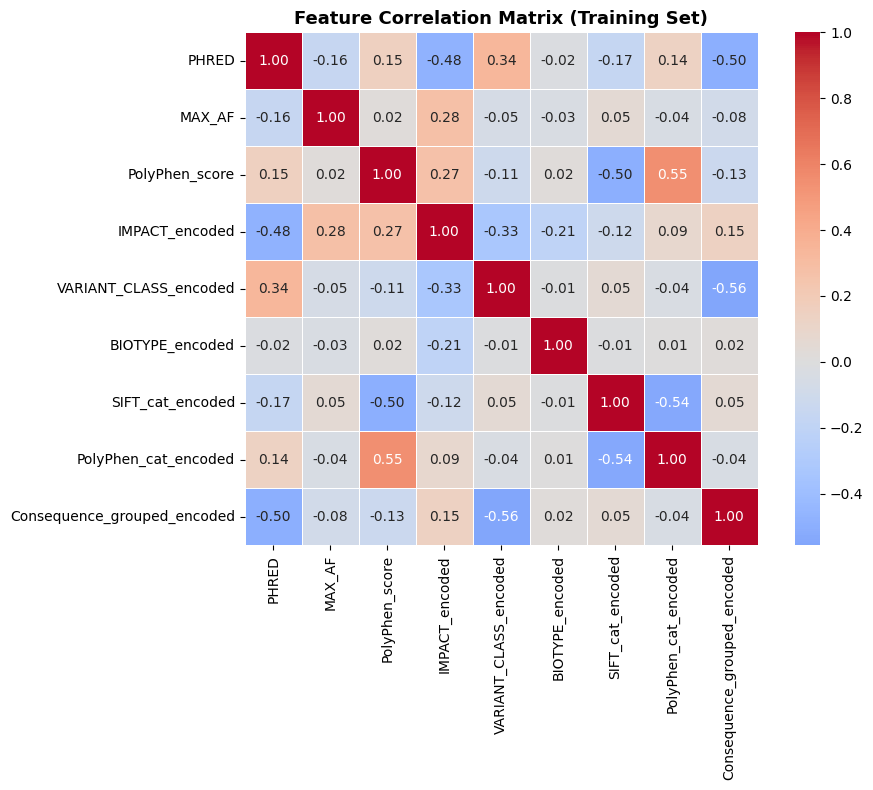

Saved: feature_correlation_final.png
                                PHRED    MAX_AF  PolyPhen_score  \
PHRED                        1.000000 -0.156052        0.149529   
MAX_AF                      -0.156052  1.000000        0.021074   
PolyPhen_score               0.149529  0.021074        1.000000   
IMPACT_encoded              -0.479422  0.277856        0.265070   
VARIANT_CLASS_encoded        0.341902 -0.054175       -0.106911   
BIOTYPE_encoded             -0.019567 -0.031370        0.022291   
SIFT_cat_encoded            -0.166966  0.051760       -0.495900   
PolyPhen_cat_encoded         0.138797 -0.042230        0.548991   
Consequence_grouped_encoded -0.504781 -0.084610       -0.125125   

                             IMPACT_encoded  VARIANT_CLASS_encoded  \
PHRED                             -0.479422               0.341902   
MAX_AF                             0.277856              -0.054175   
PolyPhen_score                     0.265070              -0.106911   
IMPACT_encod

In [3]:
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 10}, ax=ax)
ax.set_title('Feature Correlation Matrix (Training Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation_final.png', dpi=150)
plt.show()
print('Saved: feature_correlation_final.png')
print(corr)

## 4. Class Imbalance Analysis

All classifiers use `class_weight='balanced'` (or `scale_pos_weight` for XGBoost).  
`→ saves: class_imbalance.png`

Benign (0):     32,135 (63.0%)
Pathogenic (1): 18,861 (37.0%)
Imbalance ratio: 1:1.70

Computed weights — Benign: 0.7935 | Pathogenic: 1.3519


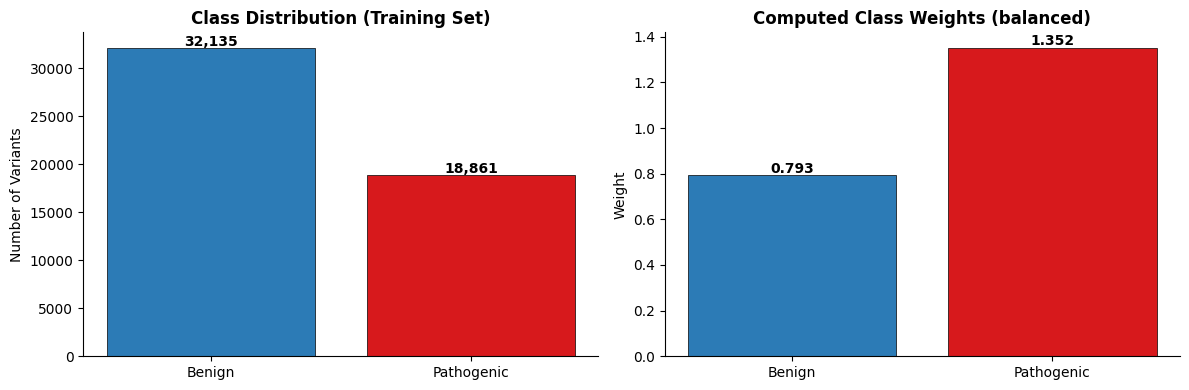

Saved: class_imbalance.png


In [4]:
class_counts = y_train.value_counts()
weights = compute_class_weight(class_weight='balanced',
                               classes=np.array([0, 1]), y=y_train)

print(f'Benign (0):     {class_counts[0]:,} ({class_counts[0]/len(y_train)*100:.1f}%)')
print(f'Pathogenic (1): {class_counts[1]:,} ({class_counts[1]/len(y_train)*100:.1f}%)')
print(f'Imbalance ratio: 1:{class_counts[0]/class_counts[1]:.2f}')
print(f'\nComputed weights — Benign: {weights[0]:.4f} | Pathogenic: {weights[1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Benign', 'Pathogenic'], [class_counts[0], class_counts[1]],
            color=[COLORS['Benign'], COLORS['Pathogenic']], edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution (Training Set)', fontweight='bold')
axes[0].set_ylabel('Number of Variants')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].bar(['Benign', 'Pathogenic'], weights,
            color=[COLORS['Benign'], COLORS['Pathogenic']], edgecolor='black', linewidth=0.5)
axes[1].set_title('Computed Class Weights (balanced)', fontweight='bold')
axes[1].set_ylabel('Weight')
for i, v in enumerate(weights):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()
print('Saved: class_imbalance.png')

## 5. Baseline Model Comparison

Four classifiers trained with default/balanced settings to identify top candidates for tuning.


In [5]:
classifiers = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight='balanced',
        random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6,
        scale_pos_weight=32135/18861,
        random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0),
    'SVM': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1)
}

results = {}
for name, clf in classifiers.items():
    print(f'Training {name}...')
    start = time.time()
    clf.fit(X_train, y_train)
    elapsed = time.time() - start
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'clf': clf, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc, 'time': elapsed}
    print(f'  Time: {elapsed:.1f}s | ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Pathogenic']))

Training Random Forest...
  Time: 0.8s | ROC-AUC: 0.9991
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      8034
  Pathogenic       0.99      0.99      0.99      4715

    accuracy                           0.99     12749
   macro avg       0.99      0.99      0.99     12749
weighted avg       0.99      0.99      0.99     12749

Training XGBoost...
  Time: 3.4s | ROC-AUC: 0.9991
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      8034
  Pathogenic       0.99      0.99      0.99      4715

    accuracy                           0.99     12749
   macro avg       0.99      0.99      0.99     12749
weighted avg       0.99      0.99      0.99     12749

Training SVM...
  Time: 26.9s | ROC-AUC: 0.9957
              precision    recall  f1-score   support

      Benign       0.99      0.97      0.98      8034
  Pathogenic       0.95      0.99      0.97      4715

    accuracy              

## 6. Hyperparameter Tuning

5-fold GridSearchCV on Random Forest and XGBoost (the two best-performing baselines).  
Scored on ROC-AUC.


In [6]:
# ── Random Forest ──────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}
print('Tuning Random Forest...')
start = time.time()
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print(f'RF tuning time: {time.time()-start:.1f}s')
print(f'Best RF params: {rf_grid.best_params_}')
print(f'Best RF CV AUC: {rf_grid.best_score_:.4f}')

# ── XGBoost ────────────────────────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample':     [0.8, 1.0]
}
print('\nTuning XGBoost...')
start = time.time()
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=32135/18861, random_state=42,
                  n_jobs=-1, eval_metric='logloss', verbosity=0),
    xgb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train)
print(f'XGB tuning time: {time.time()-start:.1f}s')
print(f'Best XGB params: {xgb_grid.best_params_}')
print(f'Best XGB CV AUC: {xgb_grid.best_score_:.4f}')

Tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
RF tuning time: 64.8s
Best RF params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV AUC: 0.9992

Tuning XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
XGB tuning time: 13.1s
Best XGB params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best XGB CV AUC: 0.9991


## 7. Tuned Model Evaluation

Retrain with best hyperparameters, then run 10-fold CV to confirm stability.


In [7]:
# Best params from GridSearch (update if re-tuned)
rf_best = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    min_samples_leaf=2, min_samples_split=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_best.fit(X_train, y_train)
rf_prob = rf_best.predict_proba(X_test)[:, 1]
rf_pred = rf_best.predict(X_test)
rf_auc  = roc_auc_score(y_test, rf_prob)

xgb_best = XGBClassifier(
    n_estimators=100, max_depth=4,
    learning_rate=0.1, subsample=0.8,
    scale_pos_weight=32135/18861,
    random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0
)
xgb_best.fit(X_train, y_train)
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]
xgb_pred = xgb_best.predict(X_test)
xgb_auc  = roc_auc_score(y_test, xgb_prob)

print('=== Tuned Random Forest ===')
print(f'Test ROC-AUC: {rf_auc:.4f}')
print(classification_report(y_test, rf_pred, target_names=['Benign', 'Pathogenic']))

print('\n=== Tuned XGBoost ===')
print(f'Test ROC-AUC: {xgb_auc:.4f}')
print(classification_report(y_test, xgb_pred, target_names=['Benign', 'Pathogenic']))

=== Tuned Random Forest ===
Test ROC-AUC: 0.9995
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      8034
  Pathogenic       0.99      0.99      0.99      4715

    accuracy                           0.99     12749
   macro avg       0.99      0.99      0.99     12749
weighted avg       0.99      0.99      0.99     12749


=== Tuned XGBoost ===
Test ROC-AUC: 0.9995
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99      8034
  Pathogenic       0.99      0.99      0.99      4715

    accuracy                           0.99     12749
   macro avg       0.99      0.99      0.99     12749
weighted avg       0.99      0.99      0.99     12749



In [8]:
print('Running 10-fold CV...')
rf_cv  = cross_val_score(rf_best,  X_train, y_train, cv=10, scoring='roc_auc', n_jobs=-1)
xgb_cv = cross_val_score(xgb_best, X_train, y_train, cv=10, scoring='roc_auc', n_jobs=-1)

print(f'RF  10-fold CV AUC: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print(f'XGB 10-fold CV AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

Running 10-fold CV...
RF  10-fold CV AUC: 0.9992 ± 0.0004
XGB 10-fold CV AUC: 0.9992 ± 0.0004


### 7.1 ROC Curve with Bootstrap 95% CI  
`→ saves: roc_curve_CI.png`

RF  AUC: 0.9995  (95% CI: 0.9993–0.9997)
XGB AUC: 0.9995 (95% CI: 0.9992–0.9997)


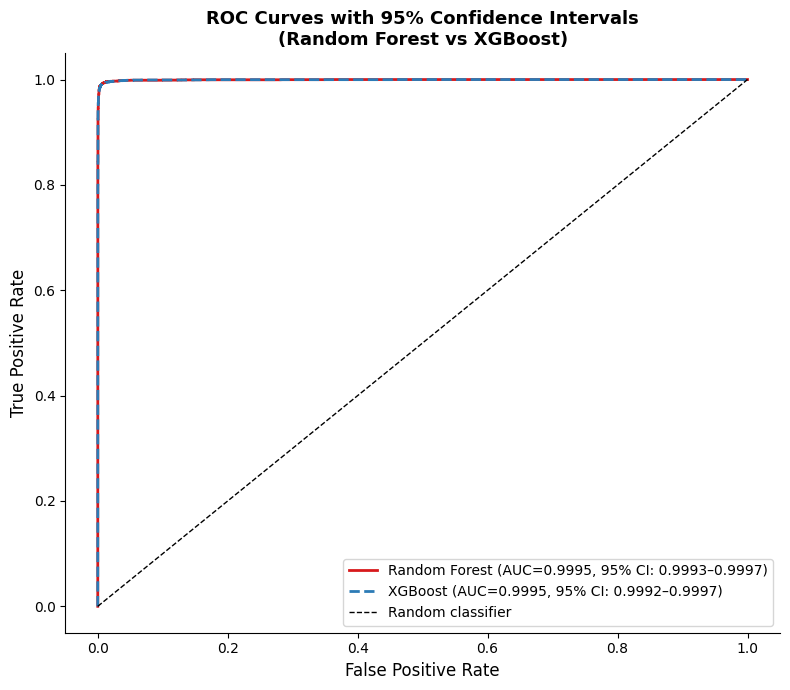

Saved: roc_curve_CI.png


In [9]:
n_bootstrap = 1000
rf_aucs, xgb_aucs = [], []
np.random.seed(42)
for i in range(n_bootstrap):
    idx = resample(np.arange(len(y_test)), random_state=i)
    rf_aucs.append(roc_auc_score(y_test.iloc[idx], rf_prob[idx]))
    xgb_aucs.append(roc_auc_score(y_test.iloc[idx], xgb_prob[idx]))

rf_ci  = (np.percentile(rf_aucs,  2.5), np.percentile(rf_aucs,  97.5))
xgb_ci = (np.percentile(xgb_aucs, 2.5), np.percentile(xgb_aucs, 97.5))

print(f'RF  AUC: {rf_auc:.4f}  (95% CI: {rf_ci[0]:.4f}–{rf_ci[1]:.4f})')
print(f'XGB AUC: {xgb_auc:.4f} (95% CI: {xgb_ci[0]:.4f}–{xgb_ci[1]:.4f})')

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_rf,  tpr_rf,  color='#D7191C', lw=2,
        label=f'Random Forest (AUC={rf_auc:.4f}, 95% CI: {rf_ci[0]:.4f}–{rf_ci[1]:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#2C7BB6', lw=2, linestyle='--',
        label=f'XGBoost (AUC={xgb_auc:.4f}, 95% CI: {xgb_ci[0]:.4f}–{xgb_ci[1]:.4f})')
ax.fill_between(fpr_rf, tpr_rf - np.std(rf_aucs), tpr_rf + np.std(rf_aucs),
                alpha=0.1, color='#D7191C')
ax.plot([0,1], [0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves with 95% Confidence Intervals\n(Random Forest vs XGBoost)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curve_CI.png', dpi=150)
plt.show()
print('Saved: roc_curve_CI.png')

### 7.2 Precision-Recall Curve & Clinical Threshold Selection

Pathogenic threshold selected at the point where precision ≥ 0.99 with maximum recall.  
Benign threshold set at 0.30.  
`→ saves: precision_recall_curve.png`

RF  Average Precision: 0.9993
XGB Average Precision: 0.9993

Selected Pathogenic threshold: 0.5193
  Precision @ threshold: 0.9900
  Recall @ threshold:    0.9909

Three-zone scheme:
  Pathogenic: prob >= 0.5193
  VUS:        0.30 <= prob < 0.5193
  Benign:     prob < 0.30


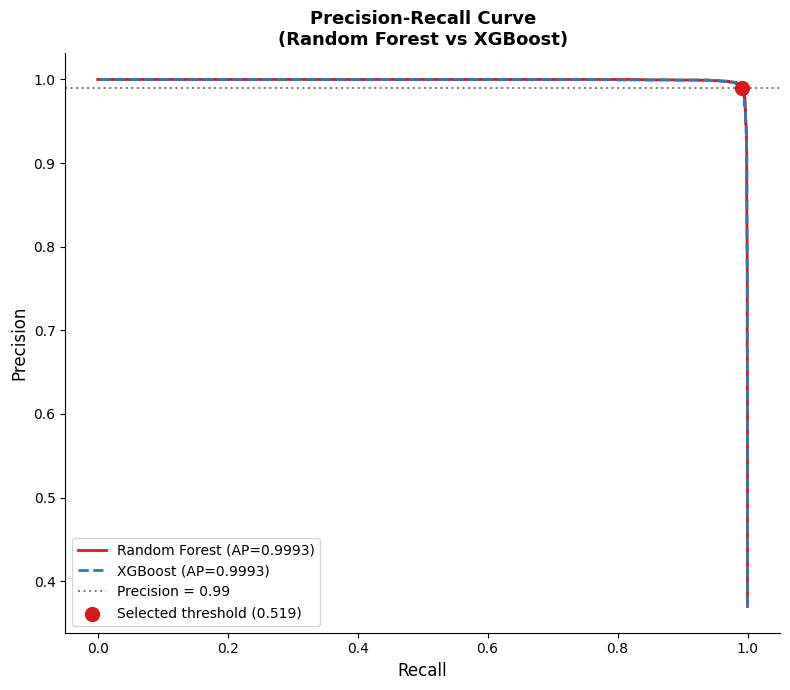

Saved: precision_recall_curve.png


In [10]:
precision_rf, recall_rf, thresholds_rf     = precision_recall_curve(y_test, rf_prob)
precision_xgb, recall_xgb, thresholds_xgb  = precision_recall_curve(y_test, xgb_prob)

ap_rf  = average_precision_score(y_test, rf_prob)
ap_xgb = average_precision_score(y_test, xgb_prob)

# Select threshold: precision >= 0.99, maximise recall
target_precision = 0.99
valid_idx = np.where(precision_rf[:-1] >= target_precision)[0]
best_idx  = valid_idx[np.argmax(recall_rf[valid_idx])]
pathogenic_threshold = thresholds_rf[best_idx]
benign_threshold     = 0.30

print(f'RF  Average Precision: {ap_rf:.4f}')
print(f'XGB Average Precision: {ap_xgb:.4f}')
print(f'\nSelected Pathogenic threshold: {pathogenic_threshold:.4f}')
print(f'  Precision @ threshold: {precision_rf[best_idx]:.4f}')
print(f'  Recall @ threshold:    {recall_rf[best_idx]:.4f}')
print(f'\nThree-zone scheme:')
print(f'  Pathogenic: prob >= {pathogenic_threshold:.4f}')
print(f'  VUS:        {benign_threshold:.2f} <= prob < {pathogenic_threshold:.4f}')
print(f'  Benign:     prob < {benign_threshold:.2f}')

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(recall_rf,  precision_rf,  color='#D7191C', lw=2, label=f'Random Forest (AP={ap_rf:.4f})')
ax.plot(recall_xgb, precision_xgb, color='#2C7BB6', lw=2, linestyle='--', label=f'XGBoost (AP={ap_xgb:.4f})')
ax.axhline(y=0.99, color='gray', linestyle=':', lw=1.5, label='Precision = 0.99')
ax.scatter(recall_rf[best_idx], precision_rf[best_idx], color='#D7191C', s=100, zorder=5,
           label=f'Selected threshold ({pathogenic_threshold:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve\n(Random Forest vs XGBoost)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()
print('Saved: precision_recall_curve.png')

## 8. Three-Zone Classification

Apply the clinical thresholds to produce three-zone predictions on the test set.
Also compute confidence zones (high/low conf) for downstream reporting.


In [11]:
# Three-zone classifier
def classify_variant(prob):
    if prob >= pathogenic_threshold: return 'Pathogenic'
    elif prob < benign_threshold:    return 'Benign'
    else:                            return 'VUS'

# Five-zone confidence classifier
def confidence_zone(prob):
    if prob >= 0.80:                       return 'High conf Pathogenic'
    elif prob >= pathogenic_threshold:     return 'Low conf Pathogenic'
    elif prob >= benign_threshold:         return 'VUS zone'
    elif prob >= 0.20:                     return 'Low conf Benign'
    else:                                  return 'High conf Benign'

test_results = X_test.copy()
test_results['true_label']      = y_test.values
test_results['rf_prob']         = rf_prob
test_results['predicted_class'] = [classify_variant(p) for p in rf_prob]
test_results['confidence_zone'] = [confidence_zone(p) for p in rf_prob]

print('=== Three-Zone Distribution ===')
print(test_results['predicted_class'].value_counts())

print('\n=== For TRUE Pathogenic ===')
print(test_results[test_results['true_label']==1]['predicted_class'].value_counts())

print('\n=== For TRUE Benign ===')
print(test_results[test_results['true_label']==0]['predicted_class'].value_counts())

=== Three-Zone Distribution ===
predicted_class
Benign        7963
Pathogenic    4719
VUS             67
Name: count, dtype: int64

=== For TRUE Pathogenic ===
predicted_class
Pathogenic    4672
Benign          24
VUS             19
Name: count, dtype: int64

=== For TRUE Benign ===
predicted_class
Benign        7939
VUS             48
Pathogenic      47
Name: count, dtype: int64


In [12]:
# High-confidence accuracy
y_test_reset = y_test.reset_index(drop=True)
conf_preds   = test_results['confidence_zone'].reset_index(drop=True)

hc_patho       = ((conf_preds == 'High conf Pathogenic') & (y_test_reset==1)).sum()
hc_patho_total = (conf_preds == 'High conf Pathogenic').sum()
hc_benign       = ((conf_preds == 'High conf Benign') & (y_test_reset==0)).sum()
hc_benign_total = (conf_preds == 'High conf Benign').sum()

print(f'High conf Pathogenic: {hc_patho}/{hc_patho_total} correct ({hc_patho/hc_patho_total*100:.2f}%)')
print(f'High conf Benign:     {hc_benign}/{hc_benign_total} correct ({hc_benign/hc_benign_total*100:.2f}%)')
print(f'Total high confidence: {hc_patho_total + hc_benign_total} ({(hc_patho_total + hc_benign_total)/len(conf_preds)*100:.1f}%)')

High conf Pathogenic: 4629/4646 correct (99.63%)
High conf Benign:     7901/7919 correct (99.77%)
Total high confidence: 12565 (98.6%)


## 9. Visualisation Suite

Five publication-ready figures covering model performance and error analysis.


### Plot 1: Confusion Matrix  
`→ saves: plot_01_confusion_matrix.png`

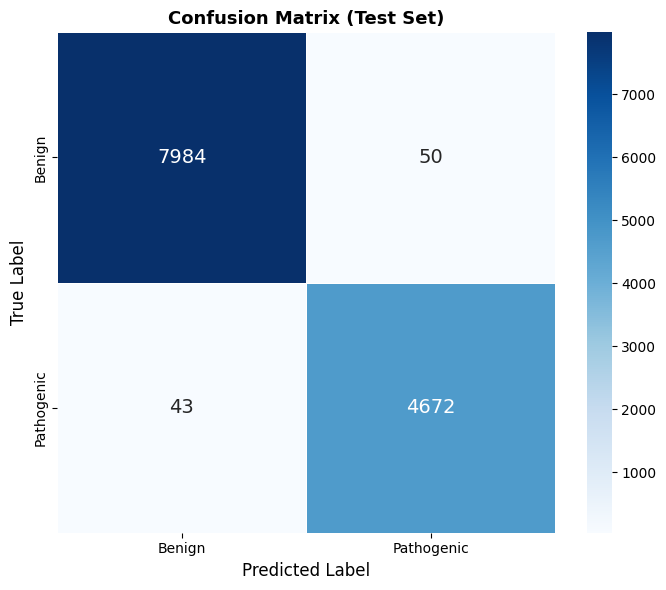

Saved: plot_01_confusion_matrix.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, rf_best.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Pathogenic'],
            yticklabels=['Benign', 'Pathogenic'],
            annot_kws={'size': 14}, linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: plot_01_confusion_matrix.png')

### Plot 2: Predicted Probability Distribution  
`→ saves: plot_02_probability_distribution.png`

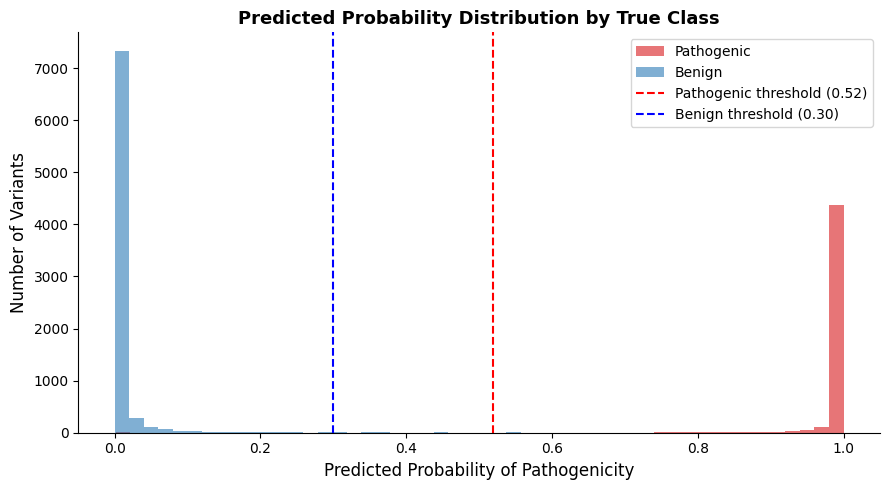

Saved: plot_02_probability_distribution.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in [(1, '#D7191C'), (0, '#2C7BB6')]:
    subset = test_results[test_results['true_label'] == label]['rf_prob']
    ax.hist(subset, bins=50, alpha=0.6, color=color,
            label='Pathogenic' if label==1 else 'Benign', edgecolor='none')
ax.axvline(x=pathogenic_threshold, color='red',  linestyle='--', lw=1.5,
           label=f'Pathogenic threshold ({pathogenic_threshold:.2f})')
ax.axvline(x=benign_threshold,     color='blue', linestyle='--', lw=1.5,
           label=f'Benign threshold ({benign_threshold:.2f})')
ax.set_xlabel('Predicted Probability of Pathogenicity', fontsize=12)
ax.set_ylabel('Number of Variants', fontsize=12)
ax.set_title('Predicted Probability Distribution by True Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot_02_probability_distribution.png', dpi=150)
plt.show()
print('Saved: plot_02_probability_distribution.png')

### Plot 3: Three-Zone Classification Breakdown  
`→ saves: plot_03_three_zone.png`

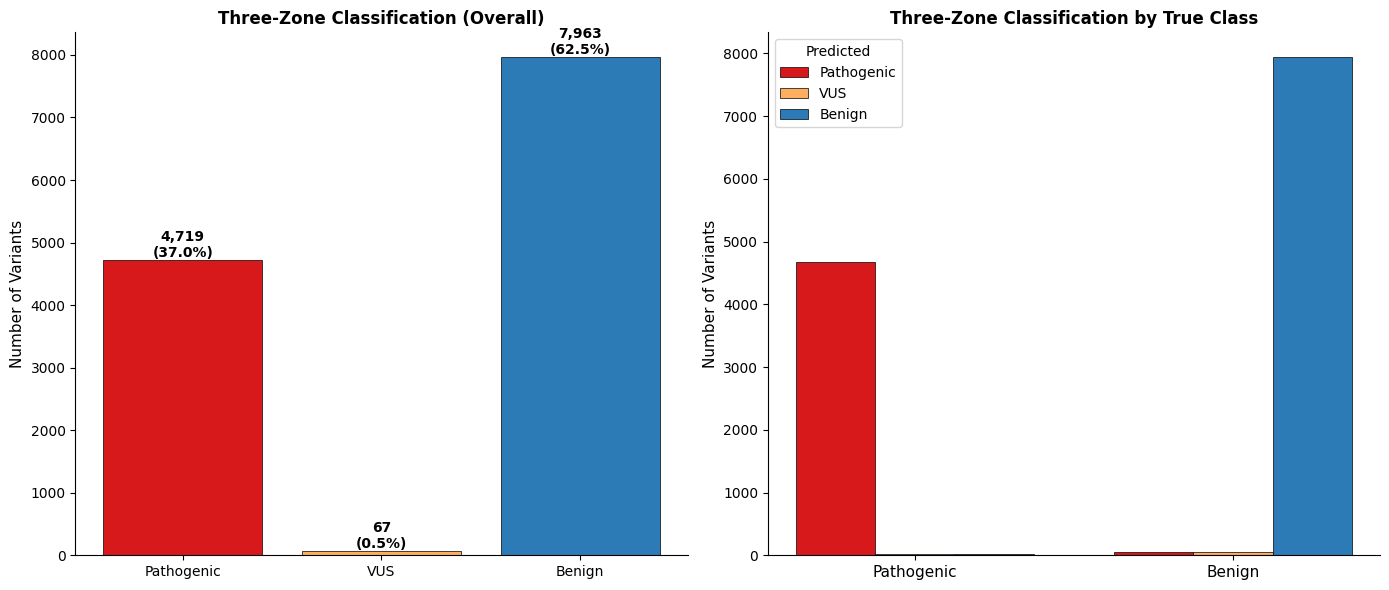

Saved: plot_03_three_zone.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall
overall_counts = test_results['predicted_class'].value_counts().reindex(['Pathogenic', 'VUS', 'Benign'])
axes[0].bar(overall_counts.index, overall_counts.values,
            color=[COLORS[c] for c in overall_counts.index], edgecolor='black', linewidth=0.5)
for i, (idx, val) in enumerate(overall_counts.items()):
    axes[0].text(i, val + 50, f'{val:,}\n({val/len(test_results)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Three-Zone Classification (Overall)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Variants', fontsize=11)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# By true class
x, width = np.arange(2), 0.25
for i, pred in enumerate(['Pathogenic', 'VUS', 'Benign']):
    counts = [
        len(test_results[(test_results['true_label']==1) & (test_results['predicted_class']==pred)]),
        len(test_results[(test_results['true_label']==0) & (test_results['predicted_class']==pred)])
    ]
    axes[1].bar(x + i*width, counts, width, label=pred, color=COLORS[pred], edgecolor='black', linewidth=0.5)
axes[1].set_xticks(x + width); axes[1].set_xticklabels(['Pathogenic', 'Benign'], fontsize=11)
axes[1].set_title('Three-Zone Classification by True Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Variants', fontsize=11)
axes[1].legend(title='Predicted', fontsize=10)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot_03_three_zone.png', dpi=150)
plt.show()
print('Saved: plot_03_three_zone.png')

### Plot 4: Confidence Zone Distribution & Accuracy  
`→ saves: plot_04_confidence_breakdown.png`

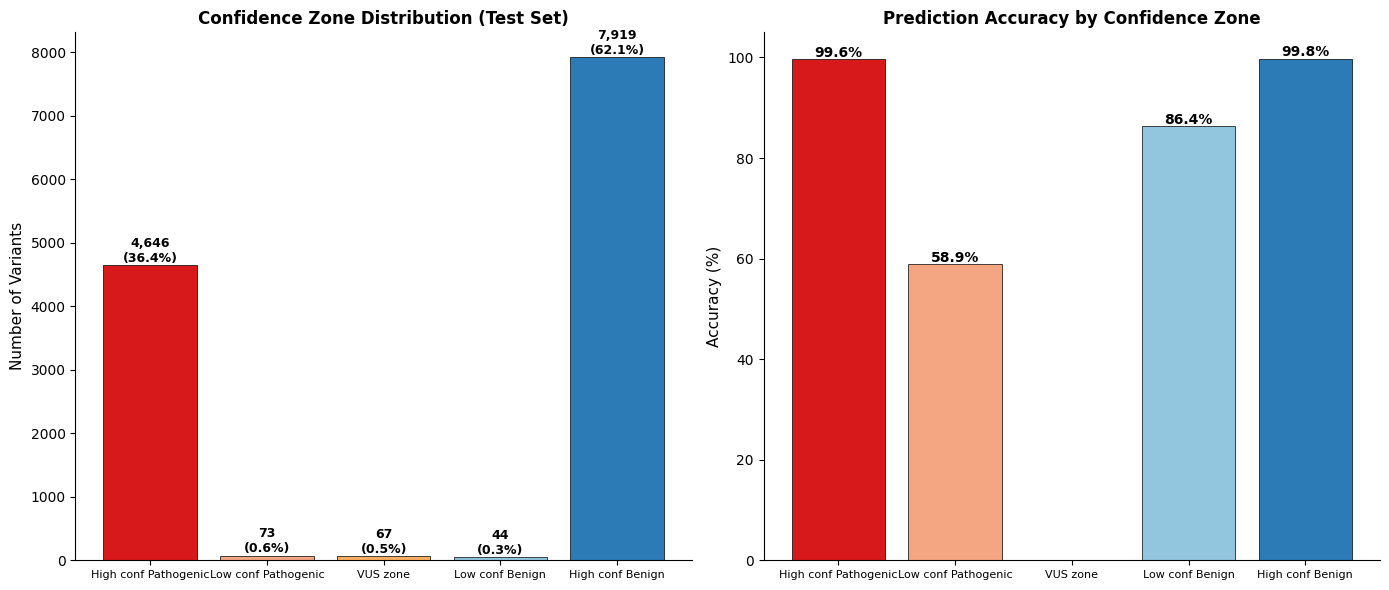

Saved: plot_04_confidence_breakdown.png


In [16]:
zone_order  = ['High conf Pathogenic', 'Low conf Pathogenic', 'VUS zone',
               'Low conf Benign', 'High conf Benign']
zone_colors = {'High conf Pathogenic': '#D7191C', 'Low conf Pathogenic': '#F4A582',
               'VUS zone': '#FDAE61', 'Low conf Benign': '#92C5DE',
               'High conf Benign': '#2C7BB6'}

zone_counts = test_results['confidence_zone'].value_counts().reindex(zone_order).fillna(0)

# Accuracy per zone
zone_accuracy = []
for zone in zone_order:
    zone_df = test_results[test_results['confidence_zone'] == zone]
    if 'Pathogenic' in zone:
        correct = (zone_df['true_label'] == 1).sum()
    elif 'Benign' in zone:
        correct = (zone_df['true_label'] == 0).sum()
    else:
        correct = 0
    zone_accuracy.append(correct / len(zone_df) * 100 if len(zone_df) > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bar_colors = [zone_colors[z] for z in zone_order]

axes[0].bar(zone_order, zone_counts, color=bar_colors, edgecolor='black', linewidth=0.5)
for i, val in enumerate(zone_counts):
    axes[0].text(i, val + 50, f'{int(val):,}\n({val/len(test_results)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Confidence Zone Distribution (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Variants', fontsize=11)
axes[0].tick_params(axis='x', labelsize=8)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].bar(zone_order, zone_accuracy, color=bar_colors, edgecolor='black', linewidth=0.5)
for i, val in enumerate(zone_accuracy):
    if val > 0:
        axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Prediction Accuracy by Confidence Zone', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', labelsize=8)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot_04_confidence_breakdown.png', dpi=150)
plt.show()
print('Saved: plot_04_confidence_breakdown.png')

### Plot 5: Misclassification Analysis (FN + FP)  
`→ saves: plot_05_misclassification.png`

False Negatives (Pathogenic→Benign): 24
False Positives (Benign→Pathogenic): 47


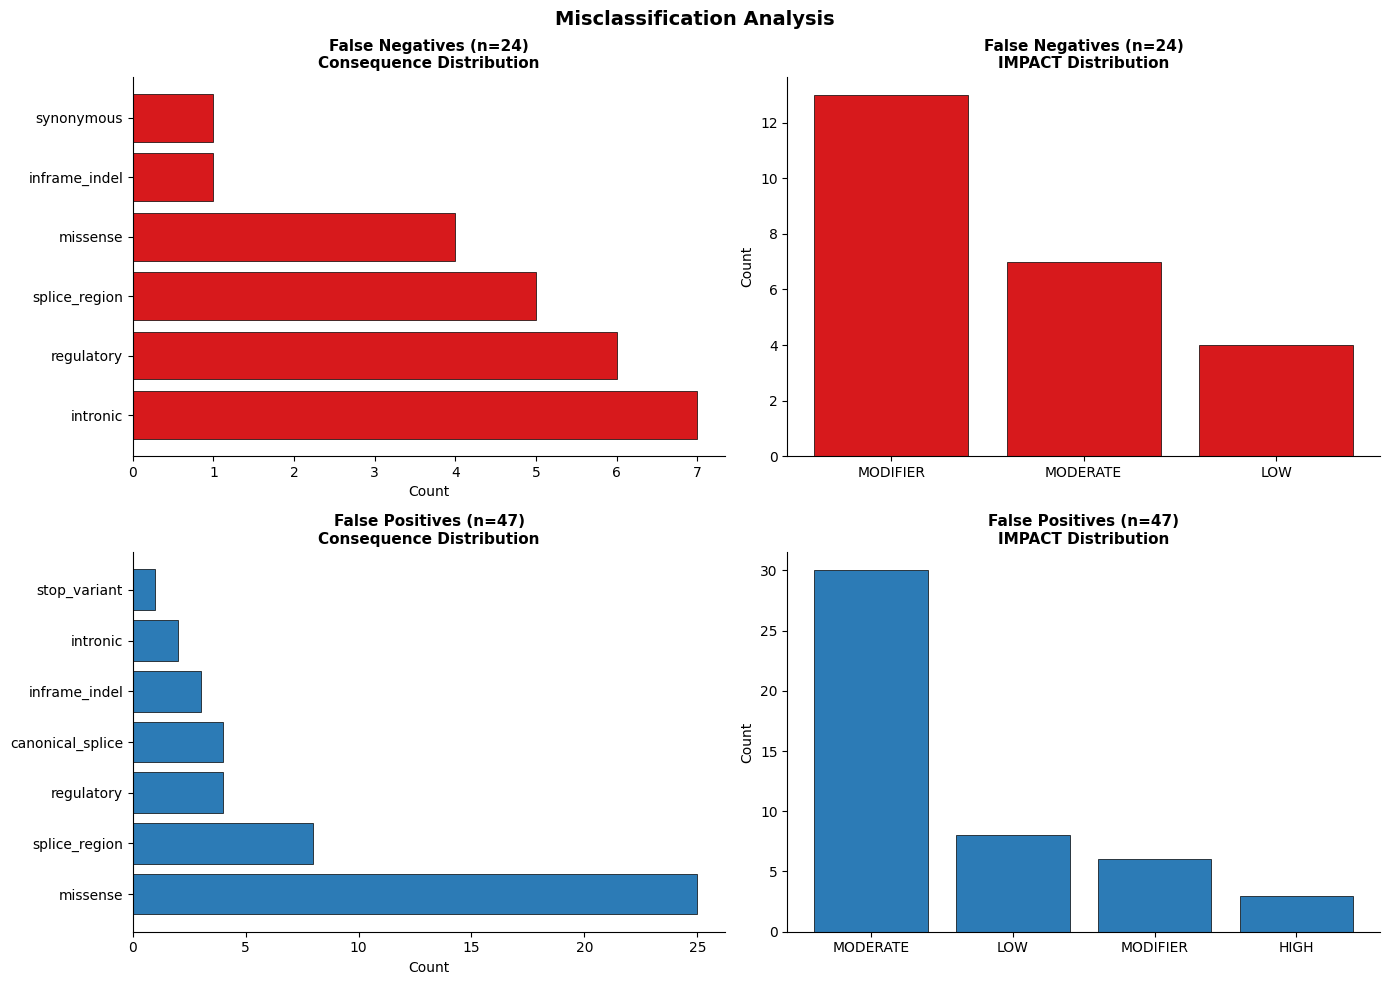

Saved: plot_05_misclassification.png


In [17]:
consequence_map = {0:'UTR', 1:'canonical_splice', 2:'frameshift', 3:'inframe_indel',
                   4:'intronic', 5:'missense', 6:'other', 7:'regulatory',
                   8:'splice_region', 9:'stop_variant', 10:'synonymous'}
impact_map = {0:'HIGH', 1:'LOW', 2:'MODERATE', 3:'MODIFIER'}

false_negatives = test_results[
    (test_results['true_label']==1) & (test_results['predicted_class']=='Benign')].copy()
false_positives = test_results[
    (test_results['true_label']==0) & (test_results['predicted_class']=='Pathogenic')].copy()

for err_df in [false_negatives, false_positives]:
    err_df['Consequence_label'] = err_df['Consequence_grouped_encoded'].map(consequence_map)
    err_df['IMPACT_label']      = err_df['IMPACT_encoded'].map(impact_map)

print(f'False Negatives (Pathogenic→Benign): {len(false_negatives)}')
print(f'False Positives (Benign→Pathogenic): {len(false_positives)}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (err_df, label, color) in enumerate([
        (false_negatives, 'False Negatives', '#D7191C'),
        (false_positives, 'False Positives', '#2C7BB6')]):
    cons_counts   = err_df['Consequence_label'].value_counts()
    impact_counts = err_df['IMPACT_label'].value_counts()

    axes[row,0].barh(cons_counts.index, cons_counts.values, color=color, edgecolor='black', linewidth=0.5)
    axes[row,0].set_title(f'{label} (n={len(err_df)})\nConsequence Distribution',
                          fontsize=11, fontweight='bold')
    axes[row,0].set_xlabel('Count', fontsize=10)
    axes[row,0].spines['top'].set_visible(False); axes[row,0].spines['right'].set_visible(False)

    axes[row,1].bar(impact_counts.index, impact_counts.values, color=color, edgecolor='black', linewidth=0.5)
    axes[row,1].set_title(f'{label} (n={len(err_df)})\nIMPACT Distribution',
                          fontsize=11, fontweight='bold')
    axes[row,1].set_ylabel('Count', fontsize=10)
    axes[row,1].spines['top'].set_visible(False); axes[row,1].spines['right'].set_visible(False)

plt.suptitle('Misclassification Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_misclassification.png', dpi=150)
plt.show()
print('Saved: plot_05_misclassification.png')

## 10. Artefact Export

Save models, splits, feature list, and config JSON for downstream notebooks.


In [18]:
with open('rf_model_tuned.pkl',     'wb') as f: pickle.dump(rf_best,    f)
with open('xgb_model_tuned.pkl',    'wb') as f: pickle.dump(xgb_best,   f)
with open('feature_cols.pkl',       'wb') as f: pickle.dump(feature_cols, f)
with open('train_test_splits.pkl',  'wb') as f:
    pickle.dump({'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train, 'y_test': y_test}, f)

config = {
    'best_model':         'Random Forest',
    'rf_params':          rf_grid.best_params_,
    'xgb_params':         xgb_grid.best_params_,
    'rf_test_auc':        float(rf_auc),
    'xgb_test_auc':       float(xgb_auc),
    'rf_cv_auc_mean':     float(rf_cv.mean()),
    'rf_cv_auc_std':      float(rf_cv.std()),
    'xgb_cv_auc_mean':    float(xgb_cv.mean()),
    'xgb_cv_auc_std':     float(xgb_cv.std()),
    'rf_ci':              list(rf_ci),
    'xgb_ci':             list(xgb_ci),
    'pathogenic_threshold': pathogenic_threshold,
    'benign_threshold':     benign_threshold,
    'n_train':            len(X_train),
    'n_test':             len(X_test),
    'n_vus':              len(vus_data),
    'feature_cols':       feature_cols
}

with open('model_config.json', 'w') as f: json.dump(config, f, indent=2)

print('Saved artefacts:')
for fname in ['rf_model_tuned.pkl', 'xgb_model_tuned.pkl',
              'feature_cols.pkl', 'train_test_splits.pkl', 'model_config.json']:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f'  {fname}: {size/1024/1024:.1f} MB')

Saved artefacts:
  rf_model_tuned.pkl: 9.0 MB
  xgb_model_tuned.pkl: 0.2 MB
  feature_cols.pkl: 0.0 MB
  train_test_splits.pkl: 6.3 MB
  model_config.json: 0.0 MB
